In [75]:
# Import Essentail Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Data Inspection

We will import and examine both **train** and **test** CSV files to understand their structure and identify any differences.

### Steps:
1. **Load both CSV files** – Import `train.csv` and `test.csv` into the environment.  
2. **Preview the data** – Display the first 5 rows of each using `.head()` to get an overview of the dataset.  
3. **Statistical summary** – Use `.describe()` to examine key statistics for both datasets.  
4. **Compare columns** – Ensure the only missing column in `test.csv` is the `SalePrice` target column.  
5. **Check dataset shape** – Verify the number of rows and columns in both files for consistency.  
6. **Identify missing values** – Check for null values in each dataset to determine where data cleaning is needed.  
7. **Handle missing values** – Compute imputation values (mean/median/mode) using the **training dataset only**, store them in variables, and apply those values to the **test dataset** to maintain consistency.


In [76]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [77]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [78]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [79]:
print(f'train csv has rows {train.shape[0]} and columns {train.shape[1]} \ntest csv has rows {test.shape[0]} and columns {test.shape[1]}')

train csv has rows 1460 and columns 81 
test csv has rows 1459 and columns 80


In [80]:
# Check column difference 
set(train) - set(test)

{'SalePrice'}

In [81]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [82]:
test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [83]:
print(f"Values missing in train data: \n{train.isnull().sum()}")
print(f"\n\nValues missing in test data: \n{test.isnull().sum()}")

Values missing in train data: 
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


Values missing in test data: 
Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


In [84]:
lotfrontage_median = train['LotFrontage'].median()

train['LotFrontage'] = train['LotFrontage'].fillna(lotfrontage_median)
test['LotFrontage'] = test['LotFrontage'].fillna(lotfrontage_median)

In [85]:
common = test['MSZoning'].mode()[0]
test['MSZoning'] = test['MSZoning'].fillna(common)

In [86]:
common_sales = test['SaleType'].mode()[0]
test['SaleType'] = test['SaleType'].fillna(common)

In [87]:
print(f"Values missing in train data: \n{train.isnull().sum()}")
print(f"\n\nValues missing in test data: \n{test.isnull().sum()}")

Values missing in train data: 
Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64


Values missing in test data: 
Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 80, dtype: int64


In [88]:
train['SalePrice'].unique() # To make sure there is no negative value 

array([208500, 181500, 223500, 140000, 250000, 143000, 307000, 200000,
       129900, 118000, 129500, 345000, 144000, 279500, 157000, 132000,
       149000,  90000, 159000, 139000, 325300, 139400, 230000, 154000,
       256300, 134800, 306000, 207500,  68500,  40000, 149350, 179900,
       165500, 277500, 309000, 145000, 153000, 109000,  82000, 160000,
       170000, 130250, 141000, 319900, 239686, 249700, 113000, 127000,
       177000, 114500, 110000, 385000, 130000, 180500, 172500, 196500,
       438780, 124900, 158000, 101000, 202500, 219500, 317000, 180000,
       226000,  80000, 225000, 244000, 185000, 144900, 107400,  91000,
       135750, 136500, 193500, 153500, 245000, 126500, 168500, 260000,
       174000, 164500,  85000, 123600, 109900,  98600, 163500, 133900,
       204750, 214000,  94750,  83000, 128950, 205000, 178000, 118964,
       198900, 169500, 100000, 115000, 190000, 136900, 383970, 217000,
       259500, 176000, 155000, 320000, 163990, 136000, 153900, 181000,
      

In [89]:
print(f"data types of train data: \n{train.dtypes}")
print(f"\n\ndata types of test data: \n{test.dtypes}")

data types of train data: 
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


data types of test data: 
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MiscVal            int64
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
Length: 80, dtype: object


# Visualization

### Histograms:
- Sales Price 
- LotArea 
- GrLivArea
### Scatter plots:
- SalePrice vs LotArea
- SalePrice vs GrLivArea
### Pair plot 
### Countplot
- MSZoning
### Barplot 
Neighborhood vs SalePrice
### Heatmap

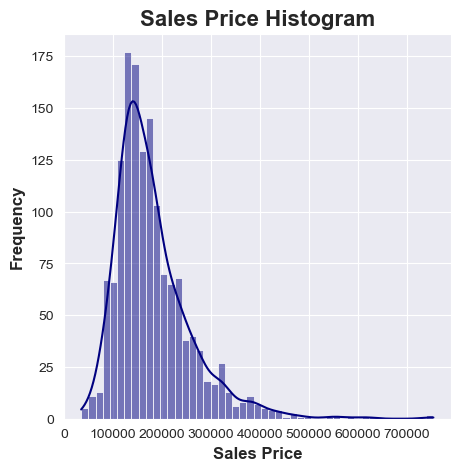

In [90]:
plt.figure(figsize=(5,5))
sns.histplot(train['SalePrice'],kde=True,bins='fd',color='navy')
plt.title("Sales Price Histogram",fontweight='bold',fontsize=16)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xlabel('Sales Price',fontweight='bold',fontsize=12)
plt.show()

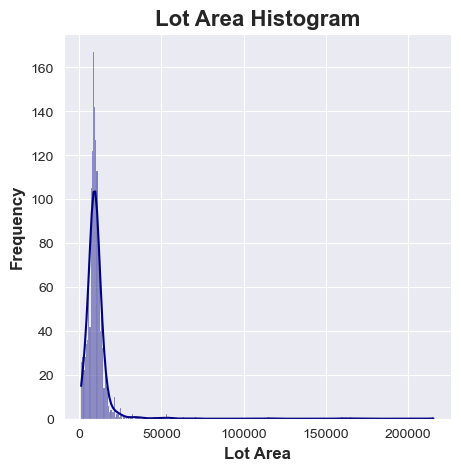

In [91]:
data = train['LotArea']
sns.set_style('darkgrid')
plt.figure(figsize=(5,5))
sns.histplot(train['LotArea'],kde=True,bins='fd',color='navy')
plt.title("Lot Area Histogram",fontweight='bold',fontsize=16)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xlabel('Lot Area',fontweight='bold',fontsize=12)
plt.show()

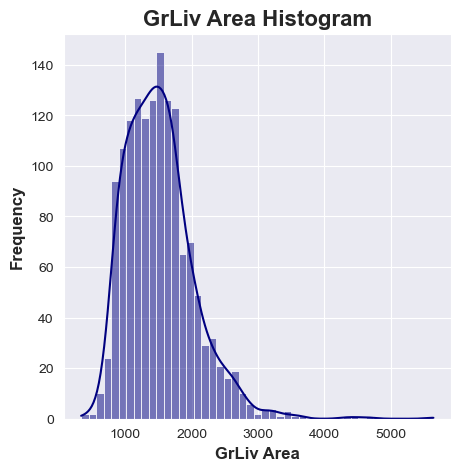

In [92]:
sns.set_style('darkgrid')
plt.figure(figsize=(5,5))
sns.histplot(train['GrLivArea'],kde=True,bins='fd',color='navy')
plt.title("GrLiv Area Histogram",fontweight='bold',fontsize=16)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xlabel('GrLiv Area',fontweight='bold',fontsize=12)
plt.show()

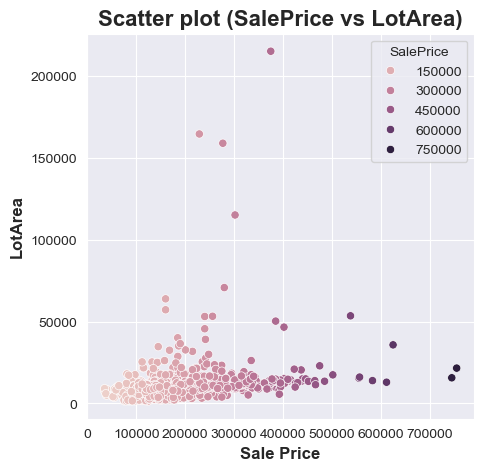

In [93]:
# Scatter plot (SalePrice vs LotArea)
sns.set_style('darkgrid')
plt.figure(figsize=(5,5))
sns.scatterplot(train,x='SalePrice',y='LotArea',hue='SalePrice')
plt.title("Scatter plot (SalePrice vs LotArea)",fontweight='bold',fontsize=16)
plt.ylabel('LotArea',fontweight='bold',fontsize=12)
plt.xlabel('Sale Price',fontweight='bold',fontsize=12)
plt.show()

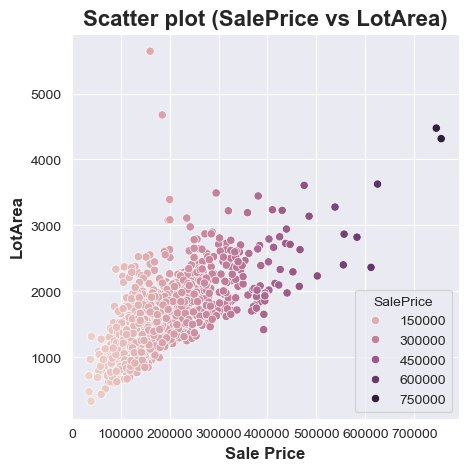

In [94]:
# Scatter plot (SalePrice vs LotArea)
sns.set_style('darkgrid')
plt.figure(figsize=(5,5))
sns.scatterplot(train,x='SalePrice',y='GrLivArea',hue='SalePrice')
plt.title("Scatter plot (SalePrice vs LotArea)",fontweight='bold',fontsize=16)
plt.ylabel('LotArea',fontweight='bold',fontsize=12)
plt.xlabel('Sale Price',fontweight='bold',fontsize=12)
plt.show()

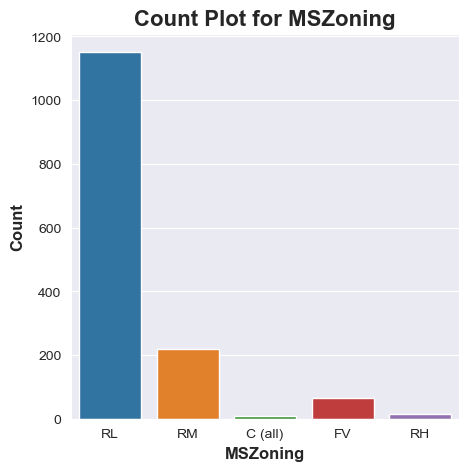

In [95]:
#count plot for MSZoning
palette = {
    'RL': '#1f77b4',  
    'RM': '#ff7f0e',   
    'C (all)': '#2ca02c',  
    'FV': '#d62728',   
    'RH': '#9467bd'    
}
sns.set_style('darkgrid')
plt.figure(figsize=(5,5))
sns.countplot(train,x='MSZoning',palette=palette,hue='MSZoning')
plt.title("Count Plot for MSZoning", fontweight='bold', fontsize=16)
plt.ylabel('Count', fontweight='bold', fontsize=12)
plt.xlabel('MSZoning', fontweight='bold', fontsize=12)

plt.show()

In [96]:
train['Neighborhood'].head()

0    CollgCr
1    Veenker
2    CollgCr
3    Crawfor
4    NoRidge
Name: Neighborhood, dtype: object

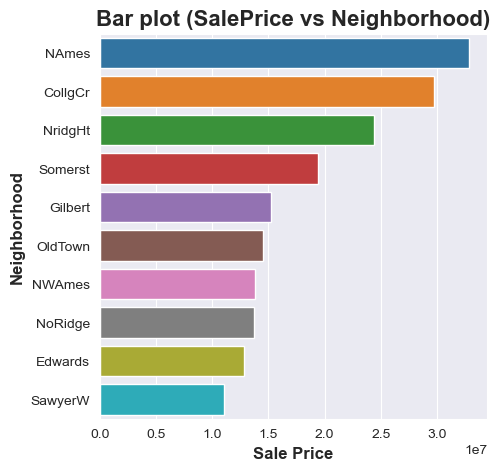

In [97]:
# Barplot for Neighborhood vs SalePrice
train_gr = train.groupby('Neighborhood')['SalePrice'].sum().reset_index()
sort_train_gr = train_gr.sort_values(by='SalePrice',ascending=False)

top_10 = sort_train_gr.head(10)

# Bar plot
sns.set_style('darkgrid')
plt.figure(figsize=(5,5))
sns.barplot(data=top_10,x='SalePrice',y='Neighborhood',hue='Neighborhood')
plt.title("Bar plot (SalePrice vs Neighborhood)",fontweight='bold',fontsize=16)
plt.ylabel('Neighborhood',fontweight='bold',fontsize=12)
plt.xlabel('Sale Price',fontweight='bold',fontsize=12)
plt.show()

<Figure size 800x1000 with 0 Axes>

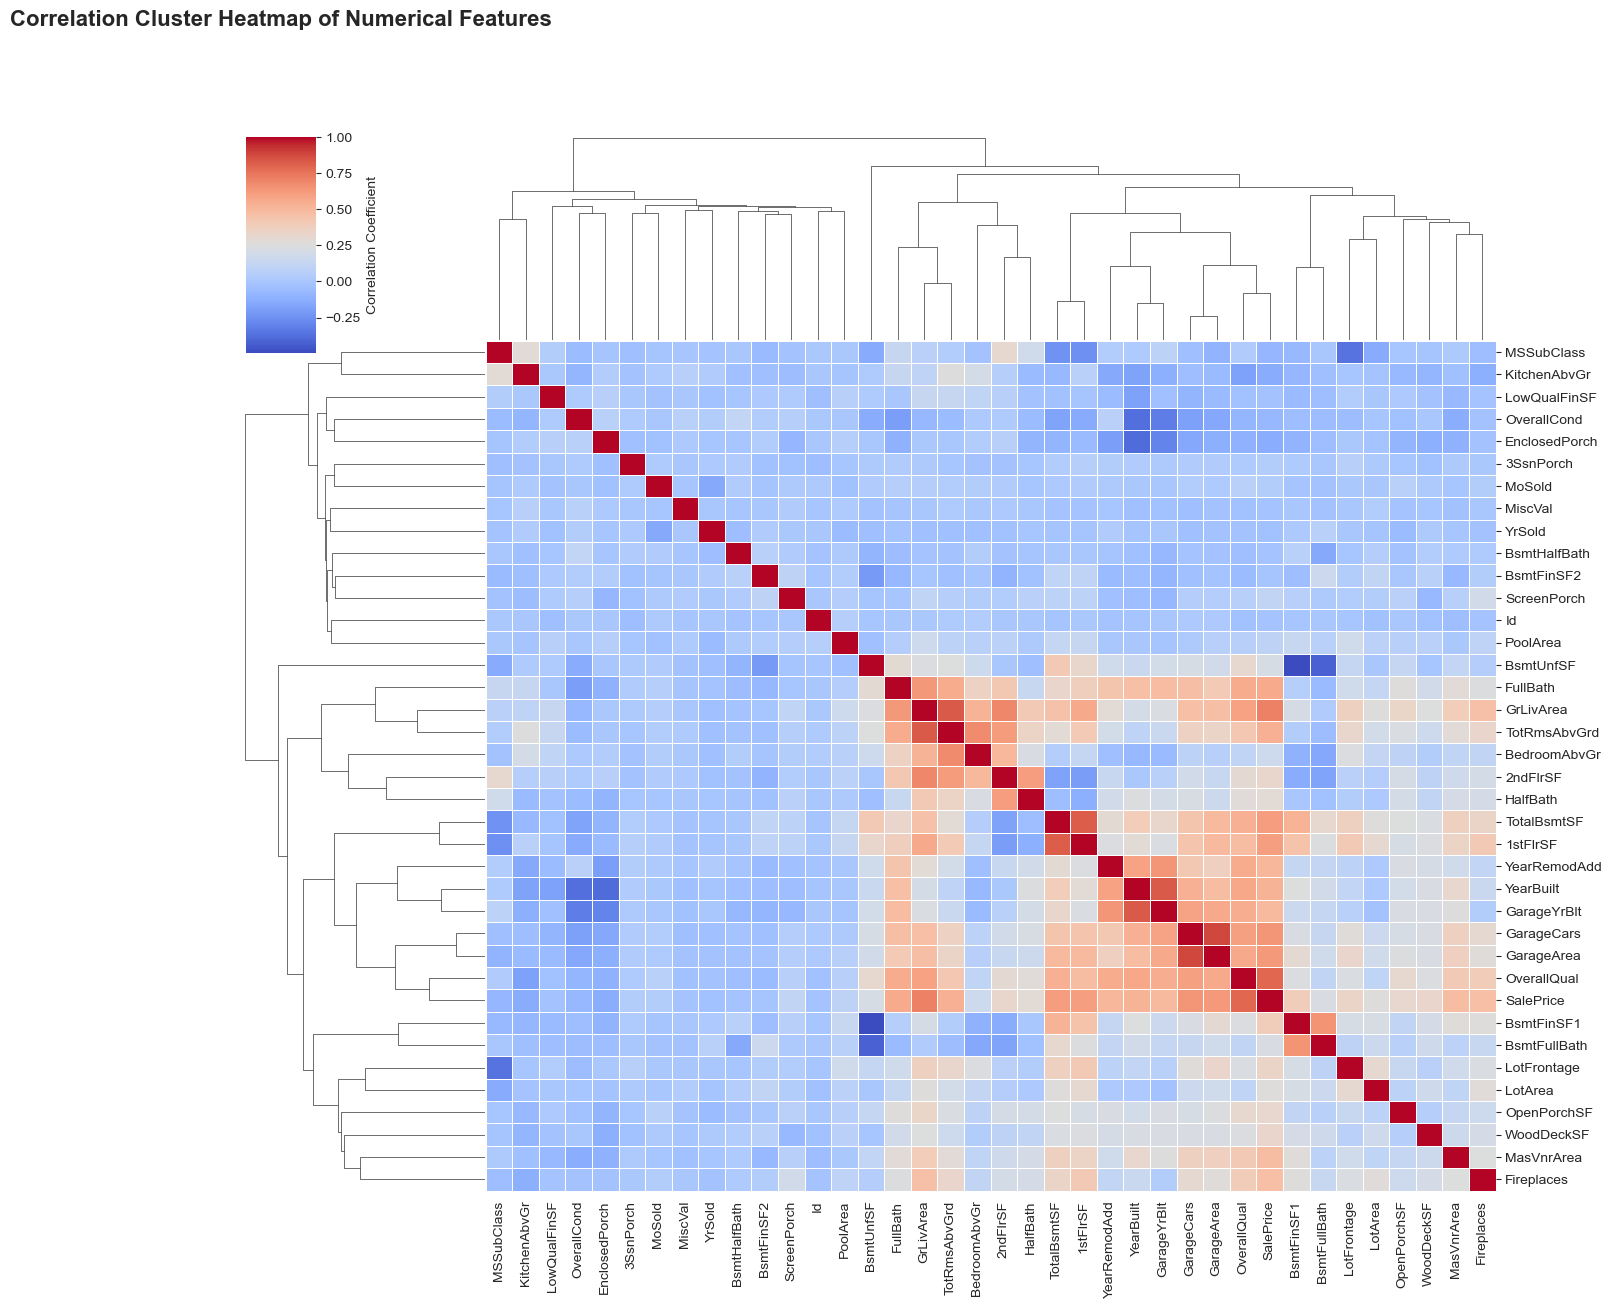

In [98]:
# Heatmap 
plt.figure(figsize=(8,10))
numeric_df = train.select_dtypes(include=['number'])
cluster = sns.clustermap(
    numeric_df.corr(),
    cmap='coolwarm',          
    linewidths=0.5,           
    figsize=(14, 12),         
    annot=False,              
    cbar_kws={'label': 'Correlation Coefficient'},  
    method='average',         
)

plt.title('Correlation Cluster Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=80)
plt.show()

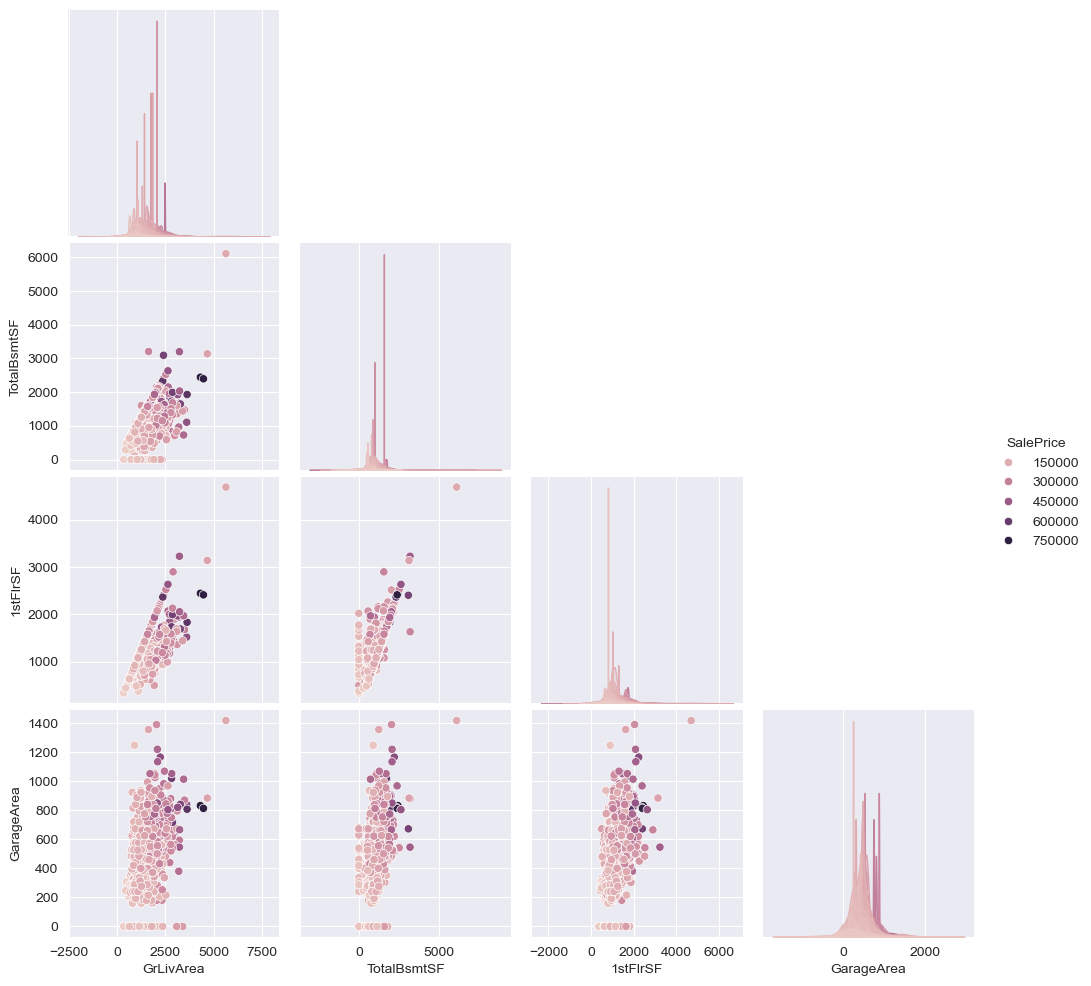

In [99]:
# Pairplot 
cols = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea']
sns.pairplot(train[cols], diag_kind='kde', corner=True,hue='SalePrice')
plt.show()

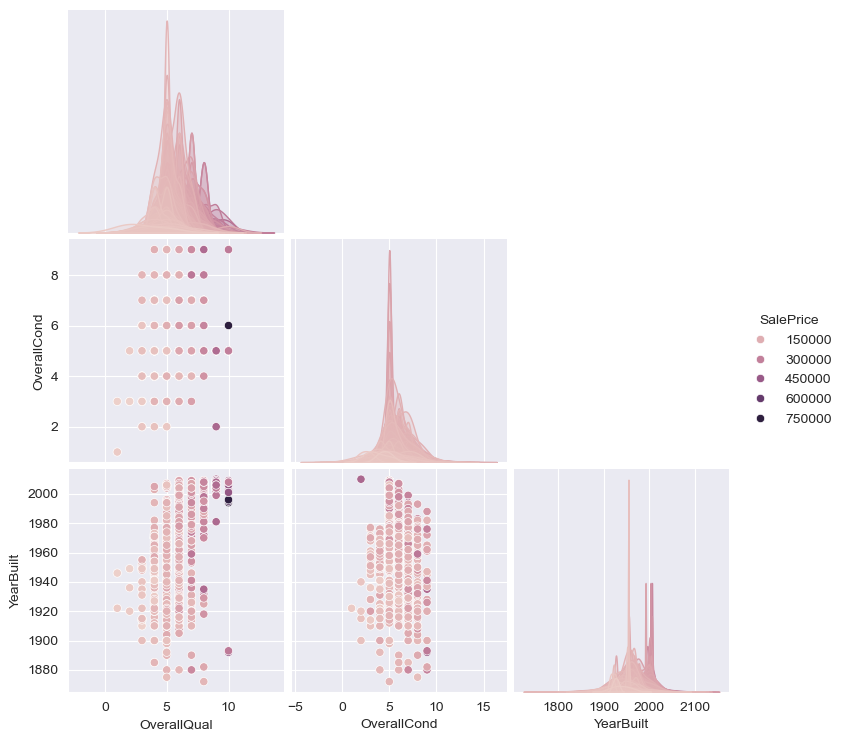

In [100]:
cols = ['SalePrice', 'OverallQual', 'OverallCond', 'YearBuilt']
sns.pairplot(train[cols], diag_kind='kde', corner=True,hue='SalePrice')
plt.show()

# Feature Engineering

### Cleaning Train datasets before encoding

In [101]:
train.isnull().sum()[train.isnull().sum() > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [102]:
train['PoolQC'].fillna('None', inplace=True)
train['MiscFeature'].fillna('None', inplace=True)
train['Alley'].fillna('None', inplace=True)
train['Fence'].fillna('None', inplace=True)
train['MasVnrType'].fillna('None', inplace=True)
train['FireplaceQu'].fillna('None', inplace=True)

for col in ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']:
    if train[col].dtype == 'object':
        train[col].fillna('None', inplace=True)
    else:
        train[col].fillna(0, inplace=True)

for col in ['BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']:
    train[col].fillna('None', inplace=True)

train['MasVnrArea'].fillna(0, inplace=True)
train['Electrical'].fillna(train['Electrical'].mode()[0], inplace=True)


C:\Users\hp\AppData\Local\Temp\ipykernel_6320\332370129.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['PoolQC'].fillna('None', inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_6320\332370129.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

In [103]:
train.isnull().sum()[train.isnull().sum() > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [104]:
train['PoolQC'].fillna('None', inplace=True)
train['MiscFeature'].fillna('None', inplace=True)
train['Alley'].fillna('None', inplace=True)
train['Fence'].fillna('None', inplace=True)
train['MasVnrType'].fillna('None', inplace=True)
train['FireplaceQu'].fillna('None', inplace=True)

for col in ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']:
    if train[col].dtype == 'object':
        train[col].fillna('None', inplace=True)
    else:
        train[col].fillna(0, inplace=True)

for col in ['BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']:
    train[col].fillna('None', inplace=True)

train['MasVnrArea'].fillna(0, inplace=True)
train['Electrical'].fillna(train['Electrical'].mode()[0], inplace=True)


C:\Users\hp\AppData\Local\Temp\ipykernel_6320\332370129.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(0, inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_6320\332370129.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

### Cleaning test datasets before encoding

In [105]:
test.isnull().sum()[test.isnull().sum() > 0].sort_values(ascending=False)

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
GarageCond        78
GarageQual        78
GarageFinish      78
GarageYrBlt       78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
BsmtHalfBath       2
BsmtFullBath       2
Functional         2
Utilities          2
KitchenQual        1
TotalBsmtSF        1
GarageCars         1
GarageArea         1
BsmtUnfSF          1
BsmtFinSF2         1
Exterior1st        1
BsmtFinSF1         1
Exterior2nd        1
dtype: int64

In [106]:
test['PoolQC'].fillna('None', inplace=True)
test['MiscFeature'].fillna('None', inplace=True)
test['Alley'].fillna('None', inplace=True)
test['Fence'].fillna('None', inplace=True)
test['MasVnrType'].fillna('None', inplace=True)
test['FireplaceQu'].fillna('None', inplace=True)

for col in ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']:
    if test[col].dtype == 'object':
        test[col].fillna('None', inplace=True)
    else:
        test[col].fillna(0, inplace=True)

for col in ['BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']:
    test[col].fillna('None', inplace=True)

test['MasVnrArea'].fillna(0, inplace=True)

test['BsmtHalfBath'].fillna(0, inplace=True)
test['BsmtFullBath'].fillna(0, inplace=True)
test['TotalBsmtSF'].fillna(0, inplace=True)
test['GarageCars'].fillna(0, inplace=True)
test['GarageArea'].fillna(0, inplace=True)
test['BsmtUnfSF'].fillna(0, inplace=True)
test['BsmtFinSF2'].fillna(0, inplace=True)
test['BsmtFinSF1'].fillna(0, inplace=True)

test['Functional'].fillna('Typ', inplace=True)
test['Utilities'].fillna('AllPub', inplace=True)
test['KitchenQual'].fillna(test['KitchenQual'].mode()[0], inplace=True)
test['Exterior1st'].fillna(test['Exterior1st'].mode()[0], inplace=True)
test['Exterior2nd'].fillna(test['Exterior2nd'].mode()[0], inplace=True)


C:\Users\hp\AppData\Local\Temp\ipykernel_6320\3850129795.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['PoolQC'].fillna('None', inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_6320\3850129795.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when do

In [107]:
test.isnull().sum()[test.isnull().sum() > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [108]:
from sklearn.preprocessing import LabelEncoder

object_cols = train.select_dtypes(include=['object']).columns

for col in object_cols:
    lbl = LabelEncoder()
    lbl.fit(list(train[col].values) + list(test[col].values))  # fit on both
    train[col] = lbl.transform(train[col])
    test[col] = lbl.transform(test[col])

train = pd.get_dummies(train)
test = pd.get_dummies(test)

train, test = train.align(test, join='left', axis=1)
test = test.fillna(0)


# Model Stage

In [112]:
#Train/test split 
from sklearn.model_selection import train_test_split

X = train.drop(columns=['SalePrice'],axis=1)
y = train['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [115]:
X_train.shape

(1168, 80)

In [117]:
X_test.shape

(292, 80)

In [118]:
# Standarize the data 
from sklearn.preprocessing import StandardScaler

SC = StandardScaler()
X_train_SC = SC.fit_transform(X_train)
X_test_SC  = SC.transform(X_test)

### Models training

In [125]:
from sklearn.metrics import accuracy_score,r2_score,mean_squared_error

In [133]:
# linear Regression 
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train_SC, y_train)
y_pred_lr = lr.predict(X_test_SC)
r2 = r2_score(y_test, y_pred_lr)*100
rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
print(f"R²: {r2}")
print(f"RMSE: {rmse}")

R²: 84.29749406664845
RMSE: 34704.94817444591


In [132]:
#Random forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_SC, y_train)
y_pred_rf = rf.predict(X_test_SC)

r2 = r2_score(y_test, y_pred_rf)*100
rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5

print("R²:", r2)
print("RMSE:", rmse)

R²: 89.2506625518347
RMSE: 28714.269055394798


In [138]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

xg = XGBRegressor(random_state=42)
xg.fit(X_train_SC, y_train)
y_pred_xg = xg.predict(X_test_SC)

r2 = r2_score(y_test, y_pred_xg)*100
rmse = mean_squared_error(y_test, y_pred_xg) ** 0.5

print("R²:", r2)
print("RMSE:", rmse)

R²: 90.60851341093228
RMSE: 26839.479448859012


In [146]:
test_SC = SC.transform(test.drop('SalePrice', axis=1))

In [149]:
final_pred = xg.predict(test_SC)

array([124479.305, 157483.12 , 182631.23 , ..., 139651.73 , 115596.6  ,
       240875.88 ], dtype=float32)

In [154]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': final_pred
})
submission.to_csv('submission.csv', index=False)

In [153]:
submission

,Id,SalePrice
0,1461,124479.304688
1,1462,157483.125000
2,1463,182631.234375
3,1464,184816.531250
4,1465,202808.593750
...,...,...
1454,2915,70333.289062
1455,2916,80300.531250
1456,2917,139651.734375
1457,2918,115596.601562


# House Prices Prediction – Project Summary

This project focuses on predicting house prices using the Ames Housing dataset from Kaggle. The goal was to build and evaluate machine learning models capable of estimating the SalePrice of homes based on their features.

1. **Data Understanding and Preparation**

Imported and explored both the training and test datasets to understand their structure.

Conducted exploratory data analysis (EDA) to identify data distributions, correlations, and potential outliers.

Handled missing values using suitable methods such as median imputation for numerical features and mode or “None” for categorical features.

Verified that the dataset was clean and ready for feature engineering.

2. **Feature Engineering and Encoding**

Converted categorical variables into numerical form using Label Encoding and One-Hot Encoding.

Ensured both train and test datasets had matching feature sets.

Applied StandardScaler to normalize numerical features before model training.

3. **Model Training and Evaluation**

Split the training data into 80% training and 20% validation sets.

Trained multiple regression models, including:

Linear Regression

Random Forest Regressor

XGBoost Regressor

Evaluated all models using R² Score and RMSE (Root Mean Squared Error).

The XGBoost model performed best overall, achieving around 90% R² on the validation set, while Linear Regression had the lowest RMSE.

4. **Final Prediction and Submission**

Standardized the Kaggle test dataset using the same scaler fitted on the training data.

Generated final predictions using the XGBoost model.

Created the final submission file (submission.csv) containing the following columns:

Id

SalePrice

- Key Takeaways

Completed the full machine learning workflow: from data preprocessing and feature engineering to model evaluation and final submission.

Learned how different models behave on the same data and how scaling impacts performance.